> # Multiple Qubit gates
- **2-qubit gates**


In [1]:
from platform import python_version
import qiskit
print("Python version ", python_version())
print(f"Qiskit version: {qiskit.__version__}")

Python version  3.13.5
Qiskit version: 2.5.0


In [2]:
import numpy as np
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp, process_fidelity,Statevector

from qiskit.quantum_info import DensityMatrix

from qiskit.visualization import array_to_latex

from qiskit.circuit.library import XGate,YGate,ZGate,IGate, TGate,SGate
from qiskit.circuit import QuantumCircuit
from math import pi

***

<h1>2-Qubit gates</h1>
<h2> Also called as Controlled Gates</h2>
<ol>
    <li> CX </li>
    <li> CY </li>
    <li> CZ </li>
    <li> Controlled Hadamard </li>
    <li> Controlled Phase </li>
</ol>

***

## SWAP(not a controlled type)

## <a href="Controlled_rotations.ipynb" >Controlled Rotations: CRx,Cry,Crz</a>

***
> # Controlled NOT Gate : CX
***
### Also called as controlled-x gate
### conditional gate
### Syntax: cx(control,target)
https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.CXGate

> ### CASE 1: q0 is control, q1 is target

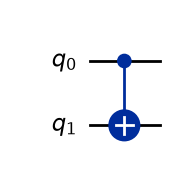

In [3]:
qc=QuantumCircuit(2)
qc.cx(0,1)
qc.draw(output="mpl")

In [4]:
array_to_latex(Operator(qc))

<IPython.core.display.Latex object>

 ![](pic9.png)

> ### CASE 2: q1 is control, q0 is target

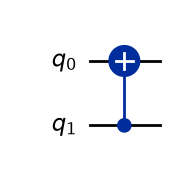

In [5]:
qc=QuantumCircuit(2)
qc.cx(1,0)
qc.draw(output="mpl")

In [6]:
array_to_latex(Operator(qc))

<IPython.core.display.Latex object>

 ![](pic10.png)

**NOTE:** 

## In Qiskit’s convention, higher qubit indices are more significant (little endian convention). 
controlled gates are presented with the assumption of more significant qubits as control, which in our case would be q_1
***

### Operation: cx gate flips the target qubit if the control qubit is in |1> state

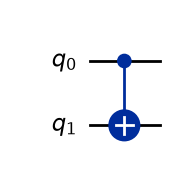

In [7]:
qc=QuantumCircuit(2)
qc.cx(0,1)
qc.draw(output="mpl")

In [8]:
state = Statevector.from_instruction(qc)

In [9]:
print(state)

Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


In [10]:
state.draw(output='latex')

<IPython.core.display.Latex object>

### Note: To see the change on the target qubit , control qubit has input as X gate

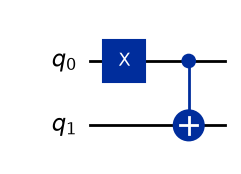

In [11]:
qc=QuantumCircuit(2)
qc.x(0)
qc.cx(0,1)
qc.draw(output="mpl")

In [12]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

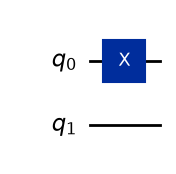

In [13]:
qc=QuantumCircuit(2)
qc.x(0)
qc.draw(output="mpl")

In [14]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

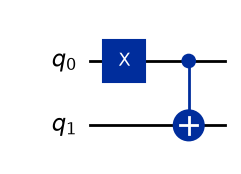

In [15]:
qc=QuantumCircuit(2)
qc.x(0)
qc.cx(0,1)
qc.draw(output="mpl")

In [16]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

***
> # Controlled Y Gate : CY
***

### Syntax: cx(control,target)

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.CYGate

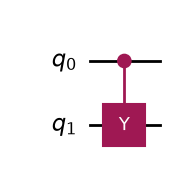

In [17]:
qc=QuantumCircuit(2)
qc.cy(0,1)
qc.draw(output="mpl")

In [18]:
array_to_latex(Operator(qc))

<IPython.core.display.Latex object>

In [19]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

### Note: Target qubit is applied Y gate when the Control qubit is in |1> state

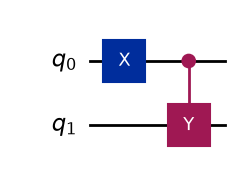

In [20]:
qc=QuantumCircuit(2)
qc.x(0)
qc.cy(0,1)
qc.draw(output="mpl")

In [21]:
array_to_latex(Operator(qc))

<IPython.core.display.Latex object>

In [22]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

***
> # Controlled Z Gate : CZ
***

IMP:
1. It is a clifford gate
2. It is also symmetric

### Syntax: cz(control,target)

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.CZGate


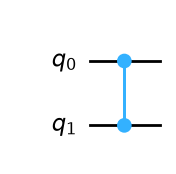

In [23]:
qc=QuantumCircuit(2)
qc.cz(0,1)
qc.draw(output="mpl")

In [24]:
array_to_latex(Operator(qc))

<IPython.core.display.Latex object>

In [25]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

### Note: Flips the phase of the target qubit when the Control qubit is in |1> state

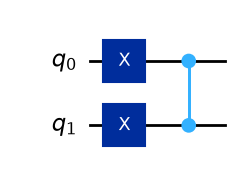

In [26]:
qc=QuantumCircuit(2)
qc.x(0)
qc.x(1)
qc.cz(0,1)
qc.draw(output="mpl")

In [27]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

> ***
# Controlled Hadamard Gate : CH
***
### Syntax: ch(control,target)

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.CHGate

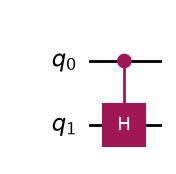

In [28]:
qc=QuantumCircuit(2)
qc.ch(0,1)
qc.draw(output="mpl")

In [29]:
array_to_latex(Operator(qc))

<IPython.core.display.Latex object>

In [30]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

### Note: Applies H to the target qubit when the Control qubit is in |1> state

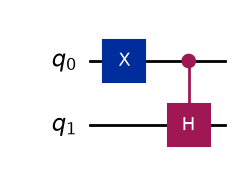

In [31]:
qc=QuantumCircuit(2)
qc.x(0)
qc.ch(0,1)
qc.draw(output="mpl")

In [32]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

***
> # Controlled Phase Gate : CP
***

### Diagonal
### Symmetric

-- induces a phase on the state of the target qubit

### Syntax: cp(control,target)

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.CPhaseGate

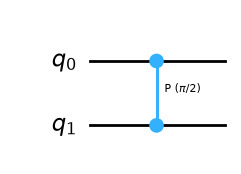

In [33]:

qc=QuantumCircuit(2)
qc.cp(pi/2,0,1)
qc.draw(output="mpl")

In [34]:
array_to_latex(Operator(qc))

<IPython.core.display.Latex object>

In [35]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

### Note: Flips the phase of the target qubit when the Control qubit is in |1> state

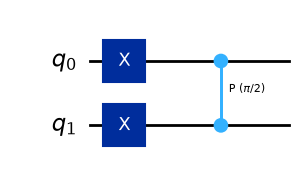

In [36]:
qc=QuantumCircuit(2)
qc.x(0)
qc.x(1)
qc.cp(pi/2,0,1)
qc.draw(output="mpl")

In [37]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

***
> # Swap Gate : swap(qubit_1,qubit_2)
***

IMP:
1. It is a clifford gate
2. It is also symmetric

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.SwapGate

### swaps/exchanges the states of the 2 qubits

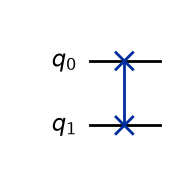

In [38]:
qc=QuantumCircuit(2)
qc.swap(0,1)
qc.draw(output="mpl")

In [39]:
array_to_latex(Operator(qc))


<IPython.core.display.Latex object>

In [40]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

## Example:

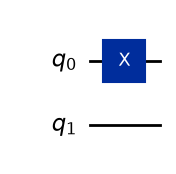

In [41]:
qc=QuantumCircuit(2)
qc.x(0)
qc.draw(output="mpl")

In [42]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

## Now apply a swap gate

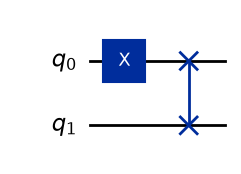

In [43]:
qc=QuantumCircuit(2)
qc.x(0)
qc.swap(0,1)
qc.draw(output="mpl")

In [44]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

> **3-Qubit gates:**
1. Toffoli gate
2. Fredkin gate

> # Toffoli gate

3-qubit gate

SYNTAX: ccx(control,control,target)

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.CCXGate

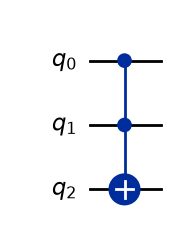

In [45]:
qc=QuantumCircuit(3)
qc.ccx(0,1,2)
qc.draw(output="mpl")

In [46]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

> Target qubit is flipped only when the first 2 control qubits are in |1> state

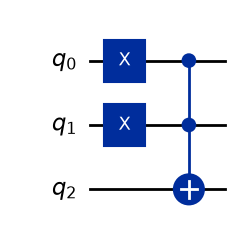

In [47]:
qc=QuantumCircuit(3)
qc.x(0)
qc.x(1)
qc.ccx(0,1,2)
qc.draw(output="mpl")

In [48]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

> # Fredkin gate
- controlled swap gate

SYNTAX: cswap(control,target1,target2)

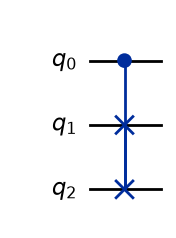

In [49]:
qc=QuantumCircuit(3)
qc.cswap(0,1,2)
qc.draw(output="mpl")

In [50]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>

>Target1 and Target 2 states are swappedonly when the control qubit is in |1> state

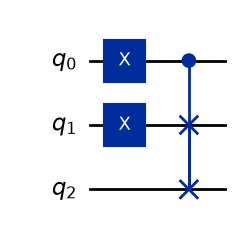

In [51]:
qc=QuantumCircuit(3)
qc.x(0)
qc.x(1)
qc.cswap(0,1,2)
qc.draw(output="mpl")

In [52]:
state = Statevector.from_instruction(qc)
state.draw(output='latex')

<IPython.core.display.Latex object>